In [ ]:
!ls /kaggle/input/datasets/dravyareddy/brats-2023

In [ ]:
data_dir = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

In [ ]:
!pip install -q \
numpy==1.26.4 \
monai==1.3.0 \
setuptools==80.0.0

In [ ]:
pip install --upgrade monai

In [ ]:
pip install monai==1.2.0

In [ ]:
import numpy as np
import monai
import torch

print("numpy:", np.__version__)
print("monai:", monai.__version__)
print("torch:", torch.__version__)

In [6]:
# =============================
# 🔥 1. IMPORTS
# =============================
import os
import time
import torch
import numpy as np
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, NormalizeIntensityd,
    CropForegroundd, RandCropByPosNegLabeld,
    RandFlipd, RandShiftIntensityd, RandScaleIntensityd,
    Lambdad, ToTensord, AsDiscrete
)
from monai.data import CacheDataset, DataLoader
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

# =============================
# ⏱️ SESSION TIMER
# Kaggle free T4 = 12 hr limit. We target 2.5–3 hrs.
# Script auto-stops and saves if budget is close to exhausted.
# =============================
SESSION_START    = time.time()
TIME_BUDGET_SECS = 2.75 * 3600   # 2 hr 45 min hard ceiling

def time_elapsed():
    return time.time() - SESSION_START

def time_remaining():
    return TIME_BUDGET_SECS - time_elapsed()

def budget_ok(buffer_secs=600):
    """Returns False when less than `buffer_secs` remain (default 10 min)."""
    return time_remaining() > buffer_secs

# =============================
# 🔥 2. DEVICE & AMP
# =============================
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
scaler  = torch.cuda.amp.GradScaler(enabled=use_amp)

torch.backends.cudnn.benchmark    = True
torch.backends.cudnn.deterministic = False

print(f"Device  : {device}")
print(f"AMP     : {use_amp}")

# =============================
# 🔥 3. HYPERPARAMETERS
# Tuned specifically for 2.5–3 hrs on Kaggle free T4
# =============================
SPATIAL_SIZE   = (96, 96, 96)  # Faster than 128³; still upgraded with AMP
FEATURE_SIZE   = 24             # 2× richer than original 12; fits easily in 16 GB
NUM_SAMPLES    = 3              # 2 crops/volume — balanced throughput vs speed
BATCH_SIZE     = 1
MAX_EPOCHS     = 60             # ~2.3 hrs training + ~10 min cache = ~2.5 hrs total
WARMUP_EPOCHS  = 5
VAL_INTERVAL   = 5              # 8 validation rounds over 40 epochs
BASE_LR        = 2e-4
NUM_CLASSES    = 4
NUM_WORKERS    = 4
CASES_TO_USE   = 80             # Less cache time vs 100; still enough data

# Early stopping
PATIENCE       = 8              # stop if no improvement for 8 val rounds (40 epochs)

# =============================
# 🔥 4. LOAD DATA
# =============================
train_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
cases = sorted(glob(os.path.join(train_path, "*")))

def get_file(case, keyword):
    for f in os.listdir(case):
        if keyword in f and (f.endswith(".nii") or f.endswith(".nii.gz")):
            path = os.path.join(case, f)
            if os.path.getsize(path) > 0:
                return path
    return None

data = []
for case in cases:
    flair = get_file(case, "t2f")
    t1    = get_file(case, "t1n")
    t1ce  = get_file(case, "t1c")
    t2    = get_file(case, "t2w")
    seg   = get_file(case, "seg")
    if None not in [flair, t1, t1ce, t2, seg]:
        data.append({"image": [flair, t1, t1ce, t2], "label": seg})

data = data[:CASES_TO_USE]
train_files, val_files = train_test_split(data, test_size=0.2, random_state=42)
print(f"Train cases : {len(train_files)}")
print(f"Val cases   : {len(val_files)}")

# =============================
# 🔥 5. TRANSFORMS
# =============================
def brats_relabel(label):
    label[label == 4] = 3
    return label

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Lambdad(keys=["label"], func=brats_relabel),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandScaleIntensityd(keys="image", factors=0.1, prob=0.5),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=0.5),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=SPATIAL_SIZE,
        pos=1, neg=1,
        num_samples=NUM_SAMPLES,
    ),
    ToTensord(keys=["image", "label"])
])

val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Lambdad(keys=["label"], func=brats_relabel),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    ToTensord(keys=["image", "label"])
])

# =============================
# 🔥 6. DATASETS & DATALOADERS
# =============================
print("\nCaching dataset (one-time, ~8–10 min)...")
cache_start = time.time()

train_ds = CacheDataset(train_files, train_transforms, cache_rate=0.4, num_workers=NUM_WORKERS)
val_ds   = CacheDataset(val_files,   val_transforms,   cache_rate=0.4, num_workers=NUM_WORKERS)

print(f"Cache done in {(time.time()-cache_start)/60:.1f} min")

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=1,
    num_workers=NUM_WORKERS, pin_memory=True
)

# =============================
# 🔥 7. MODEL
# =============================
model = SwinUNETR(
   
    in_channels=4,
    out_channels=NUM_CLASSES,
    feature_size=FEATURE_SIZE,   # 24 — double the original 12
    use_checkpoint=True,          # gradient checkpointing for VRAM safety
    spatial_dims=3,
).to(device)

print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

# =============================
# 🔥 8. RESUME FROM CHECKPOINT (if restarting session)
# Save best_model.pth as a Kaggle dataset to resume across sessions
# =============================
RESUME_PATH = "/kaggle/input/swinunetr-checkpoint/best_model.pth"  # adjust path as needed
start_epoch = 0
best_dice   = 0.0

if os.path.exists(RESUME_PATH):
    ckpt        = torch.load(RESUME_PATH, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer_state = ckpt.get("optim_state", None)
    start_epoch = ckpt.get("epoch", 0)
    best_dice   = ckpt.get("best_dice", 0.0)
    print(f"✅ Resumed from epoch {start_epoch} | Best Dice: {best_dice:.4f}")
else:
    optimizer_state = None
    print("Starting fresh training.")

# =============================
# 🔥 9. LOSS, OPTIMIZER, SCHEDULER
# =============================
loss_function = DiceCELoss(to_onehot_y=True, softmax=True, include_background=False)

optimizer = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=1e-5)
if optimizer_state:
    optimizer.load_state_dict(optimizer_state)

cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(1, MAX_EPOCHS - WARMUP_EPOCHS), eta_min=1e-6
)

dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred   = AsDiscrete(argmax=True, to_onehot=NUM_CLASSES)
post_label  = AsDiscrete(to_onehot=NUM_CLASSES)

# =============================
# 🔥 10. TRAINING LOOP
# =============================
no_improve = 0
print(f"\nStarting training: {MAX_EPOCHS} epochs | Budget: {TIME_BUDGET_SECS/3600:.1f} hrs\n")

for epoch in range(start_epoch, MAX_EPOCHS):

    # ── Time budget check ──
    if not budget_ok(buffer_secs=600):
        print(f"\n⏰ Time budget nearly exhausted at epoch {epoch+1}. Stopping safely.")
        break

    epoch_start = time.time()

    # ── LR warmup ──
    if epoch < WARMUP_EPOCHS:
        warmup_lr = BASE_LR * (epoch + 1) / WARMUP_EPOCHS
        for pg in optimizer.param_groups:
            pg["lr"] = warmup_lr

    # ── Training ──
    model.train()
    epoch_loss = 0.0

    for batch in train_loader:
        inputs = batch["image"].to(device, non_blocking=True).float()
        labels = batch["label"].to(device, non_blocking=True).long()

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
            loss    = loss_function(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    if epoch >= WARMUP_EPOCHS:
        cosine_scheduler.step()

    epoch_mins = (time.time() - epoch_start) / 60
    avg_loss   = epoch_loss / len(train_loader)
    current_lr = optimizer.param_groups[0]["lr"]
    elapsed    = time_elapsed() / 60

    print(
        f"Epoch {epoch+1:03d}/{MAX_EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"Epoch time: {epoch_mins:.1f} min | "
        f"Total elapsed: {elapsed:.1f} min | "
        f"Remaining: {time_remaining()/60:.1f} min"
    )

    # ── Validation ──
    if (epoch + 1) % VAL_INTERVAL == 0:
        model.eval()
        dice_metric.reset()
        all_preds, all_labels_list = [], []

        with torch.no_grad():
            for val in val_loader:
                val_inputs = val["image"].to(device, non_blocking=True).float()
                val_labels = val["label"].to(device, non_blocking=True).long()

                with torch.cuda.amp.autocast(enabled=use_amp):
                    val_outputs = sliding_window_inference(
                        val_inputs,
                        roi_size=SPATIAL_SIZE,
                        sw_batch_size=4,    # 4 windows in parallel — faster val
                        predictor=model,
                        overlap=0.5,
                        mode="gaussian",
                    )

                val_outputs_post = [post_pred(i)  for i in val_outputs]
                val_labels_post  = [post_label(i) for i in val_labels]
                dice_metric(y_pred=val_outputs_post, y=val_labels_post)

                # Collect for sklearn metrics
                pred_class  = torch.argmax(val_outputs, dim=1).cpu().numpy().flatten()
                label_class = val_labels.cpu().numpy().flatten()
                fg_mask     = label_class > 0
                all_preds.append(pred_class[fg_mask])
                all_labels_list.append(label_class[fg_mask])

        mean_dice  = dice_metric.aggregate().item()
        all_preds  = np.concatenate(all_preds)
        all_labels_arr = np.concatenate(all_labels_list)

        acc    = accuracy_score(all_labels_arr, all_preds)
        cm     = confusion_matrix(all_labels_arr, all_preds)
        report = classification_report(
            all_labels_arr, all_preds,
            target_names=["TC (Tumor Core)", "WT (Whole Tumor)", "ET (Enhancing)"],
            digits=4
        )

        print(f"\n Val Dice       : {mean_dice:.4f} | Best: {best_dice:.4f}")
        print(f" Voxel Accuracy : {acc:.4f}")
        print(f"\n  Classification Report:\n{report}")
        print(f"  Confusion Matrix:\n{cm}\n")

        # ── Save best ──
        if mean_dice > best_dice:
            best_dice  = mean_dice
            no_improve = 0
            torch.save({
                "epoch":       epoch + 1,
                "model_state": model.state_dict(),
                "optim_state": optimizer.state_dict(),
                "best_dice":   best_dice,
            }, "best_model.pth")
            print(f"  🔥 New best saved (Dice: {best_dice:.4f}) at epoch {epoch+1}\n")
        else:
            no_improve += 1
            print(f"  No improvement ({no_improve}/{PATIENCE})\n")

        # ── Early stopping ──
        if no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}. No improvement for {PATIENCE} val rounds.")
            break

total_mins = time_elapsed() / 60
print(f"\nDone. Total time: {total_mins:.1f} min | Best Dice: {best_dice:.4f}")

Device  : cuda
AMP     : True
Train cases : 64
Val cases   : 16

Caching dataset (one-time, ~8–10 min)...


Loading dataset: 100%|██████████| 6/6 [00:03<00:00,  1.60it/s]


Cache done in 0.3 min
Parameters : 15,705,646
Starting fresh training.

Starting training: 60 epochs | Budget: 2.8 hrs

Epoch 001/60 | Loss: 2.1893 | LR: 4.00e-05 | Epoch time: 1.2 min | Total elapsed: 1.8 min | Remaining: 163.2 min
Epoch 002/60 | Loss: 1.7953 | LR: 8.00e-05 | Epoch time: 1.2 min | Total elapsed: 3.0 min | Remaining: 162.0 min
Epoch 003/60 | Loss: 1.5767 | LR: 1.20e-04 | Epoch time: 1.2 min | Total elapsed: 4.2 min | Remaining: 160.8 min
Epoch 004/60 | Loss: 1.4072 | LR: 1.60e-04 | Epoch time: 1.2 min | Total elapsed: 5.4 min | Remaining: 159.6 min
Epoch 005/60 | Loss: 1.2374 | LR: 2.00e-04 | Epoch time: 1.2 min | Total elapsed: 6.6 min | Remaining: 158.4 min

 Val Dice       : 0.5887 | Best: 0.0000
 Voxel Accuracy : 0.7700

  Classification Report:
                  precision    recall  f1-score   support

 TC (Tumor Core)     0.9053    0.1085    0.1937    178181
WT (Whole Tumor)     0.9666    0.8507    0.9050    885684
  ET (Enhancing)     0.7316    0.9079    0.8103 

In [7]:
import os

print(os.listdir())

['best_model.pth', '.virtual_documents', 'last_checkpoint.pth']


Case: /kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/BraTS-GLI-00051-000
Model loaded
Unique pred values: [0 1 2 3]
WT: 128695 | TC: 32946 | ET: 19150
Best tumor slice: 89 (out of 155)


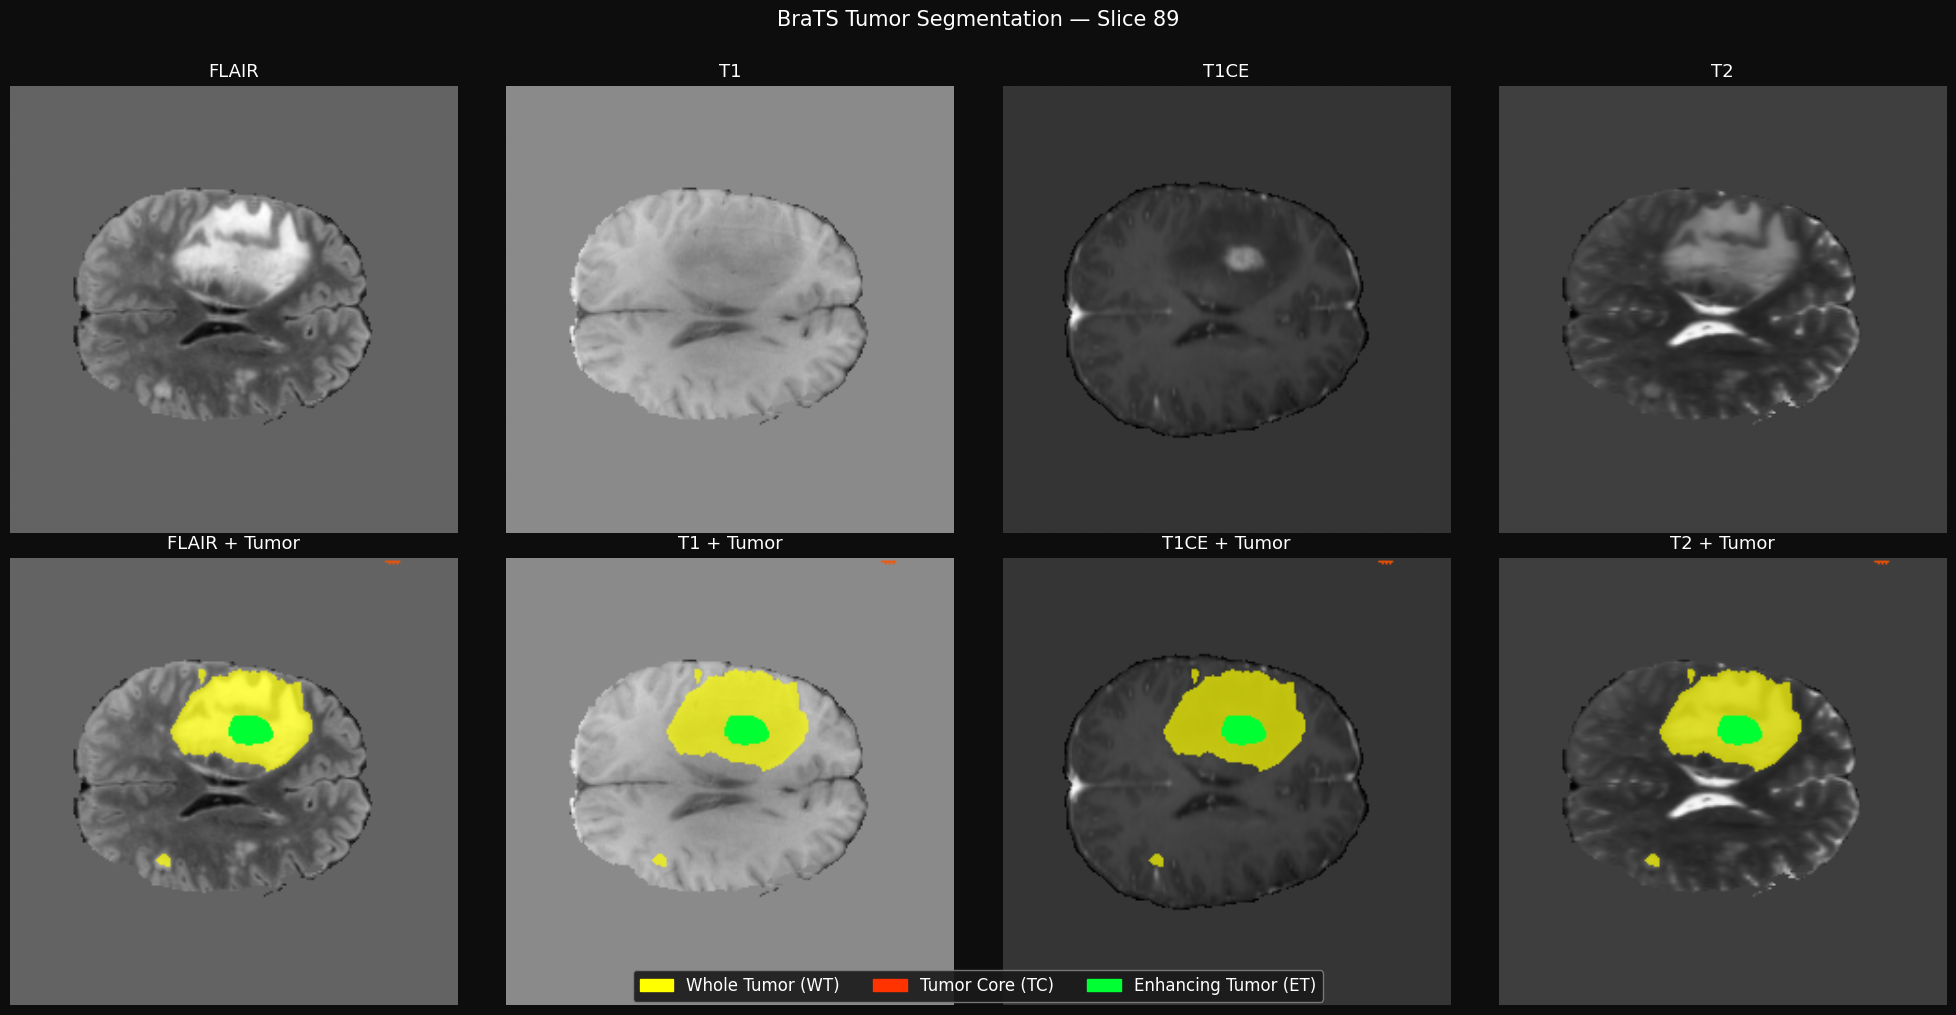

✅ Saved to tumor_overlay.png


In [12]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from scipy.ndimage import label as scipy_label

from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    Orientationd, NormalizeIntensityd, ToTensord
)
from monai.inferers import sliding_window_inference
from monai.networks.nets import SwinUNETR

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# LOAD CASE
# -------------------------
base_path = "/kaggle/input/datasets/dravyareddy/brats-2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"
cases = sorted(glob(os.path.join(base_path, "*")))

def get_file(case_path, keyword):
    for f in os.listdir(case_path):
        full = os.path.join(case_path, f)
        if keyword in f and (f.endswith(".nii") or f.endswith(".nii.gz")):
            if os.path.getsize(full) > 0:
                return full
    raise ValueError(f"{keyword} missing in {case_path}")

case_path = cases[47]
print("Case:", case_path)

data_dict = {
    "image": [
        get_file(case_path, "t2f"),
        get_file(case_path, "t1n"),
        get_file(case_path, "t1c"),
        get_file(case_path, "t2w"),
    ]
}

# -------------------------
# MODEL
# -------------------------
model = SwinUNETR(
    #img_size=(96,96,96),
    in_channels=4,
    out_channels=4,
    feature_size=24,
    spatial_dims=3
).to(device)

ckpt = torch.load("best_model.pth", map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print("Model loaded")

# -------------------------
# TRANSFORMS + INFERENCE
# -------------------------
transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys="image"),
    Orientationd(keys="image", axcodes="RAS"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    ToTensord(keys="image")
])

data    = transforms(data_dict)
image   = data["image"]
if hasattr(image, "as_tensor"):
    image = image.as_tensor()
image = image.unsqueeze(0).to(device).float()

with torch.no_grad():
    logits = sliding_window_inference(
        image,
        roi_size=(96,96,96),
        sw_batch_size=2,
        predictor=model,
        overlap=0.5
    )

pred = torch.softmax(logits, dim=1).argmax(dim=1).cpu().numpy()[0]
img_np = image.cpu().numpy()[0]

print("Unique pred values:", np.unique(pred))

# -------------------------
# CLEAN SMALL REGIONS
# -------------------------
def remove_small_regions(mask, min_size=500):
    labeled, num = scipy_label(mask)
    out = np.zeros_like(mask)
    for i in range(1, num + 1):
        if (labeled == i).sum() > min_size:
            out[labeled == i] = 1
    return out

wt = remove_small_regions(pred > 0)
tc = remove_small_regions((pred == 1) | (pred == 3))
et = remove_small_regions(pred == 3)

print(f"WT: {wt.sum()} | TC: {tc.sum()} | ET: {et.sum()}")

# -------------------------
# 🔥 FIX 1: Find best slice (most tumor, not middle)
# -------------------------
tumor_per_slice = wt.sum(axis=(0, 1))
if tumor_per_slice.max() == 0:
    slice_idx = pred.shape[-1] // 2
    print("No tumor found — showing middle slice")
else:
    slice_idx = int(tumor_per_slice.argmax())
    print(f"Best tumor slice: {slice_idx} (out of {pred.shape[-1]})")

# -------------------------
# NORMALIZE HELPER
# -------------------------
def norm(x):
    mn, mx = x.min(), x.max()
    return (x - mn) / (mx - mn + 1e-8)

# -------------------------
# 🔥 FIX 2: Proper color overlay per modality
# -------------------------
modality_names = ["FLAIR", "T1", "T1CE", "T2"]

def make_overlay(gray_slice, wt_s, tc_s, et_s):
    """Build RGB overlay on top of a grayscale slice."""
    base = norm(gray_slice)
    rgb  = np.stack([base, base, base], axis=-1).copy()
    # whole tumor → yellow (semi-transparent)
    rgb[wt_s > 0] = rgb[wt_s > 0] * 0.3 + np.array([1.0, 1.0, 0.0]) * 0.7
    # tumor core → red
    rgb[tc_s > 0] = rgb[tc_s > 0] * 0.2 + np.array([1.0, 0.2, 0.0]) * 0.8
    # enhancing tumor → bright green
    rgb[et_s > 0] = np.array([0.0, 1.0, 0.2])
    return np.clip(rgb, 0, 1)

wt_s = wt[:, :, slice_idx]
tc_s = tc[:, :, slice_idx]
et_s = et[:, :, slice_idx]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor("#0d0d0d")

for i, (name, ax_top, ax_bot) in enumerate(
    zip(modality_names, axes[0], axes[1])
):
    gray = img_np[i, :, :, slice_idx]
    overlay = make_overlay(gray, wt_s, tc_s, et_s)

    # top row — raw MRI
    ax_top.imshow(gray, cmap="gray", interpolation="bilinear")
    ax_top.set_title(name, color="white", fontsize=13, pad=6)
    ax_top.axis("off")

    # bottom row — overlay
    ax_bot.imshow(overlay, interpolation="bilinear")
    ax_bot.set_title(f"{name} + Tumor", color="white", fontsize=13, pad=6)
    ax_bot.axis("off")

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color=[1,1,0],   label="Whole Tumor (WT)"),
    Patch(color=[1,0.2,0], label="Tumor Core (TC)"),
    Patch(color=[0,1,0.2], label="Enhancing Tumor (ET)"),
]
fig.legend(handles=legend, loc="lower center", ncol=3,
           fontsize=12, facecolor="#1a1a1a", edgecolor="gray",
           labelcolor="white", framealpha=0.9,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle(f"BraTS Tumor Segmentation — Slice {slice_idx}",
             color="white", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("tumor_overlay.png", dpi=150, bbox_inches="tight",
            facecolor="#0d0d0d")
plt.show()
print("✅ Saved to tumor_overlay.png")